# Question 5

# Speech Emotion Classification Using LSTM

## Objective

The objective of this experiment is to classify human emotions from speech recordings using a Long Short-Term Memory (LSTM) neural network.

The RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song) dataset is used because it is a widely accepted benchmark dataset for speech emotion recognition. The audio recordings contain professional actors speaking with different emotional expressions.

### Dataset

**Name:** RAVDESS Emotional Speech Audio Dataset


### Selected Emotions

- Neutral
- Calm
- Happy
- Sad
- Angry
- Fearful
- Disgust
- Surprised

The dataset contains approximately 1,440 speech recordings sampled at 48 kHz.

In [6]:
import zipfile

zip_path = "/content/speech_data.zip"

extract_path = "/content/RAVDESS"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [7]:
import os

print(os.listdir("/content/RAVDESS"))

['Actor_11', 'Actor_13', 'Actor_02', 'Actor_21', 'Actor_22', 'Actor_09', 'Actor_16', 'Actor_23', 'Actor_04', 'Actor_17', 'audio_speech_actors_01-24', 'Actor_07', 'Actor_19', 'Actor_10', 'Actor_08', 'Actor_05', 'Actor_01', 'Actor_24', 'Actor_06', 'Actor_12', 'Actor_18', 'Actor_15', 'Actor_20', 'Actor_14', 'Actor_03']


In [8]:
import os
import pandas as pd

In [9]:
emotion_dict = {

    "01":"neutral",

    "02":"calm",

    "03":"happy",

    "04":"sad",

    "05":"angry",

    "06":"fearful",

    "07":"disgust",

    "08":"surprised"

}

In [10]:
dataset_path = "/content/RAVDESS"

paths = []

emotions = []

for actor in os.listdir(dataset_path):

    actor_path = os.path.join(

        dataset_path,

        actor

    )

    if not os.path.isdir(actor_path):

        continue

    for file in os.listdir(actor_path):

        if file.endswith(".wav"):

            emotion = file.split("-")[2]

            paths.append(

                os.path.join(

                    actor_path,

                    file

                )

            )

            emotions.append(

                emotion_dict[emotion]

            )

df = pd.DataFrame({

    "Path":paths,

    "Emotion":emotions

})

df.head()

,Path,Emotion
0,/content/RAVDESS/Actor_11/03-01-03-02-01-01-11...,happy
1,/content/RAVDESS/Actor_11/03-01-04-01-01-02-11...,sad
2,/content/RAVDESS/Actor_11/03-01-04-02-02-02-11...,sad
3,/content/RAVDESS/Actor_11/03-01-03-02-02-01-11...,happy
4,/content/RAVDESS/Actor_11/03-01-08-01-02-01-11...,surprised


In [12]:
print(df.shape)



(1440, 2)


In [13]:
print(

    "Number of Classes:",

    df["Emotion"].nunique()

)

print()

print(

    df["Emotion"].value_counts()

)

Number of Classes: 8

Emotion
happy        192
sad          192
surprised    192
calm         192
disgust      192
fearful      192
angry        192
neutral       96
Name: count, dtype: int64


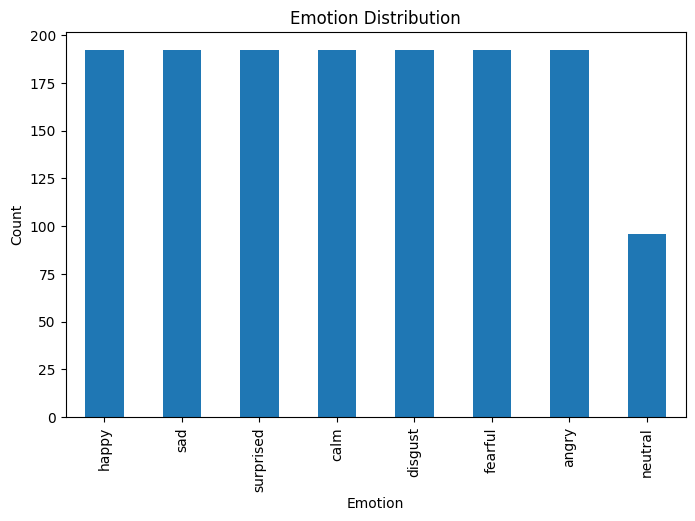

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df["Emotion"].value_counts().plot(

    kind="bar"

)

plt.title(

    "Emotion Distribution"

)

plt.xlabel("Emotion")

plt.ylabel("Count")

plt.show()

In [15]:
import librosa

sample_audio = df.iloc[0]["Path"]

y, sr = librosa.load(

    sample_audio,

    sr=None

)

duration = len(y)/sr

summary = pd.DataFrame({

    "Property":[

        "Dataset",

        "Total Samples",

        "Number of Classes",

        "Sample Rate",

        "Duration of Example"

    ],

    "Value":[

        "RAVDESS",

        len(df),

        df["Emotion"].nunique(),

        sr,

        f"{duration:.2f} sec"

    ]

})

summary

,Property,Value
0,Dataset,RAVDESS
1,Total Samples,1440
2,Number of Classes,8
3,Sample Rate,48000
4,Duration of Example,4.04 sec


# Audio Preprocessing and MFCC Feature Extraction

Each speech recording is converted into a sequence of Mel-Frequency Cepstral Coefficients (MFCCs), which capture the short-term spectral characteristics of speech.

The preprocessing pipeline consists of:

- Loading the audio file
- Converting it to mono
- Resampling to 16 kHz
- Padding or truncating to a fixed duration
- Extracting 40 MFCC coefficients

The resulting MFCC sequence is used as the input to the LSTM model.

In [16]:
import numpy as np
import librosa

class AudioPreprocessor:

    def __init__(

        self,

        sr=16000,

        duration=4,

        n_mfcc=40

    ):

        self.sr = sr

        self.duration = duration

        self.target_length = sr * duration

        self.n_mfcc = n_mfcc


    def load_audio(self, path):

        y, sr = librosa.load(

            path,

            sr=self.sr,

            mono=True

        )

        return y


    def pad_or_truncate(self, y):

        if len(y) < self.target_length:

            padding = self.target_length - len(y)

            y = np.pad(

                y,

                (0, padding)

            )

        else:

            y = y[:self.target_length]

        return y


    def extract_mfcc(self, y):

        mfcc = librosa.feature.mfcc(

            y=y,

            sr=self.sr,

            n_mfcc=self.n_mfcc

        )

        return mfcc.T


    def process(self, path):

        y = self.load_audio(path)

        y = self.pad_or_truncate(y)

        mfcc = self.extract_mfcc(y)

        return mfcc

In [17]:
preprocessor = AudioPreprocessor()

In [18]:
sample_path = df.iloc[0]["Path"]

mfcc = preprocessor.process(sample_path)

print("MFCC Shape :", mfcc.shape)

MFCC Shape : (126, 40)


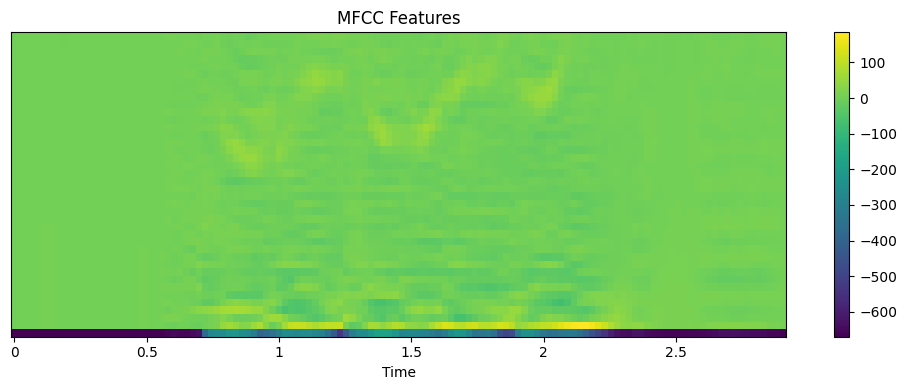

In [19]:
import librosa.display
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

librosa.display.specshow(

    mfcc.T,

    x_axis="time",

    cmap="viridis"

)

plt.colorbar()

plt.title("MFCC Features")

plt.tight_layout()

plt.show()

# Dataset and DataLoader

The extracted MFCC sequences are converted into tensors and paired with their corresponding emotion labels.

The dataset is split into training, validation, and testing subsets. PyTorch DataLoaders are then created to efficiently load batches of sequential MFCC features during model training.

In [20]:
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [21]:
encoder = LabelEncoder()

df["Label"] = encoder.fit_transform(df["Emotion"])

classes = encoder.classes_

print(classes)

['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']


In [22]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Label"],
    random_state=42
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["Label"],
    random_state=42
)

print("Train :", len(train_df))
print("Validation :", len(val_df))
print("Test :", len(test_df))

Train : 921
Validation : 231
Test : 288


In [23]:
class EmotionDataset(Dataset):

    def __init__(self, dataframe, preprocessor):

        self.df = dataframe.reset_index(drop=True)

        self.preprocessor = preprocessor


    def __len__(self):

        return len(self.df)


    def __getitem__(self, idx):

        path = self.df.loc[idx, "Path"]

        label = self.df.loc[idx, "Label"]

        mfcc = self.preprocessor.process(path)

        mfcc = torch.tensor(
            mfcc,
            dtype=torch.float32
        )

        label = torch.tensor(
            label,
            dtype=torch.long
        )

        return mfcc, label

In [24]:
train_dataset = EmotionDataset(
    train_df,
    preprocessor
)

val_dataset = EmotionDataset(
    val_df,
    preprocessor
)

test_dataset = EmotionDataset(
    test_df,
    preprocessor
)

In [25]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32
)

In [26]:
features, labels = next(iter(train_loader))

print("Input Shape :", features.shape)

print("Labels Shape :", labels.shape)

Input Shape : torch.Size([32, 126, 40])
Labels Shape : torch.Size([32])


# LSTM Model Architecture

A Long Short-Term Memory (LSTM) network is used to classify speech emotions from MFCC sequences.

The MFCC sequence is treated as a temporal signal where each time frame contains 40 acoustic features. The final hidden state of the LSTM is passed through fully connected layers to predict one of the eight emotion classes.

In [34]:
import torch.nn as nn
class EmotionLSTM(nn.Module):

    def __init__(self, input_size=40,
                 hidden_size=256,
                 num_layers=1,
                 num_classes=8):

        super().__init__()

        self.lstm = nn.LSTM(

            input_size=input_size,

            hidden_size=hidden_size,

            num_layers=num_layers,

            batch_first=True,

            dropout=0.3

        )

        self.fc = nn.Sequential(

            nn.Linear(hidden_size,64),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(64,num_classes)

        )

    def forward(self,x):

        output,(hidden,cell)=self.lstm(x)

        out=hidden[-1]

        out=self.fc(out)

        return out

In [35]:
device = torch.device(

    "cuda"

    if torch.cuda.is_available()

    else

    "cpu"

)

model = EmotionLSTM().to(device)

print(model)

EmotionLSTM(
  (lstm): LSTM(40, 256, batch_first=True, dropout=0.3)
  (fc): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=8, bias=True)
  )
)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/rnn.py:1013: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  super().__init__("LSTM", *args, **kwargs)


In [36]:
sample, label = next(iter(train_loader))

sample = sample.to(device)

output = model(sample)

print(output.shape)

torch.Size([32, 8])


In [37]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(

    model.parameters(),

    lr=0.001

)


# Model Training

The LSTM model is trained using the training dataset while monitoring the validation accuracy after every epoch. Cross-entropy loss is used as the objective function and the Adam optimizer is used for parameter optimization.

In [39]:
train_losses = []

train_accuracies = []

val_accuracies = []

epochs = 20

for epoch in range(epochs):

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for features, labels in train_loader:

        features = features.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(features)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)

        correct += (predicted==labels).sum().item()

    train_loss = running_loss/len(train_loader)

    train_accuracy = correct/total

    train_losses.append(train_loss)

    train_accuracies.append(train_accuracy)


    model.eval()

    correct = 0

    total = 0

    with torch.no_grad():

        for features, labels in val_loader:

            features = features.to(device)

            labels = labels.to(device)

            outputs = model(features)

            _, predicted = torch.max(outputs,1)

            total += labels.size(0)

            correct += (predicted==labels).sum().item()

    val_accuracy = correct/total

    val_accuracies.append(val_accuracy)

    print(

        f"Epoch {epoch+1}/{epochs} | "

        f"Loss: {train_loss:.4f} | "

        f"Train Acc: {train_accuracy:.4f} | "

        f"Val Acc: {val_accuracy:.4f}"

    )

Epoch 1/20 | Loss: 2.0353 | Train Acc: 0.1824 | Val Acc: 0.1688
Epoch 2/20 | Loss: 1.9592 | Train Acc: 0.2237 | Val Acc: 0.2641
Epoch 3/20 | Loss: 1.8727 | Train Acc: 0.2465 | Val Acc: 0.2597
Epoch 4/20 | Loss: 1.7937 | Train Acc: 0.2780 | Val Acc: 0.3420
Epoch 5/20 | Loss: 1.7194 | Train Acc: 0.3279 | Val Acc: 0.3290
Epoch 6/20 | Loss: 1.6641 | Train Acc: 0.3485 | Val Acc: 0.3723
Epoch 7/20 | Loss: 1.6137 | Train Acc: 0.3670 | Val Acc: 0.3550
Epoch 8/20 | Loss: 1.5788 | Train Acc: 0.3800 | Val Acc: 0.4199
Epoch 9/20 | Loss: 1.4961 | Train Acc: 0.4452 | Val Acc: 0.4632
Epoch 10/20 | Loss: 1.4480 | Train Acc: 0.4647 | Val Acc: 0.4329
Epoch 11/20 | Loss: 1.3820 | Train Acc: 0.4897 | Val Acc: 0.5065
Epoch 12/20 | Loss: 1.3035 | Train Acc: 0.5396 | Val Acc: 0.4719
Epoch 13/20 | Loss: 1.2523 | Train Acc: 0.5559 | Val Acc: 0.4892
Epoch 14/20 | Loss: 1.2113 | Train Acc: 0.5613 | Val Acc: 0.4935
Epoch 15/20 | Loss: 1.1469 | Train Acc: 0.5841 | Val Acc: 0.5108
Epoch 16/20 | Loss: 1.0992 | Train

The best validation accuracy of 57.58% was achieved at Epoch 17. After that, the validation accuracy decreased while the training accuracy continued to improve, indicating the onset of overfitting.

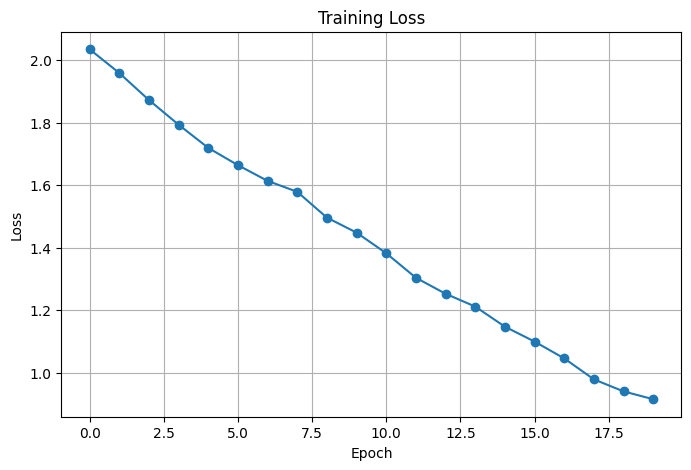

In [40]:
plt.figure(figsize=(8,5))

plt.plot(

    train_losses,

    marker="o"

)

plt.title("Training Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.show()

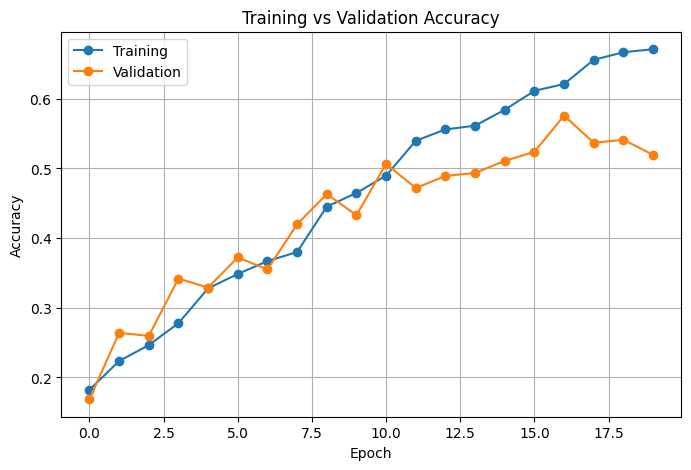

In [41]:
plt.figure(figsize=(8,5))

plt.plot(

    train_accuracies,

    marker="o",

    label="Training"

)

plt.plot(

    val_accuracies,

    marker="o",

    label="Validation"

)

plt.title("Training vs Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [42]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

model.eval()

all_predictions = []

all_labels = []

with torch.no_grad():

    for features, labels in test_loader:

        features = features.to(device)

        labels = labels.to(device)

        outputs = model(features)

        _, predicted = torch.max(outputs,1)

        all_predictions.extend(
            predicted.cpu().numpy()
        )

        all_labels.extend(
            labels.cpu().numpy()
        )

In [43]:
accuracy = accuracy_score(
    all_labels,
    all_predictions
)

precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)

recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)

f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print(f"Accuracy  : {accuracy:.4f}")

print(f"Precision : {precision:.4f}")

print(f"Recall    : {recall:.4f}")

print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.5312
Precision : 0.4647
Recall    : 0.4982
F1 Score  : 0.4734


In [44]:
print(

    classification_report(

        all_labels,

        all_predictions,

        target_names=classes

    )

)

              precision    recall  f1-score   support

       angry       0.70      0.84      0.76        38
        calm       0.53      0.68      0.60        38
     disgust       0.60      0.63      0.62        38
     fearful       0.44      0.56      0.49        39
       happy       0.50      0.26      0.34        39
     neutral       0.00      0.00      0.00        19
         sad       0.27      0.29      0.28        38
   surprised       0.68      0.72      0.70        39

    accuracy                           0.53       288
   macro avg       0.46      0.50      0.47       288
weighted avg       0.50      0.53      0.50       288



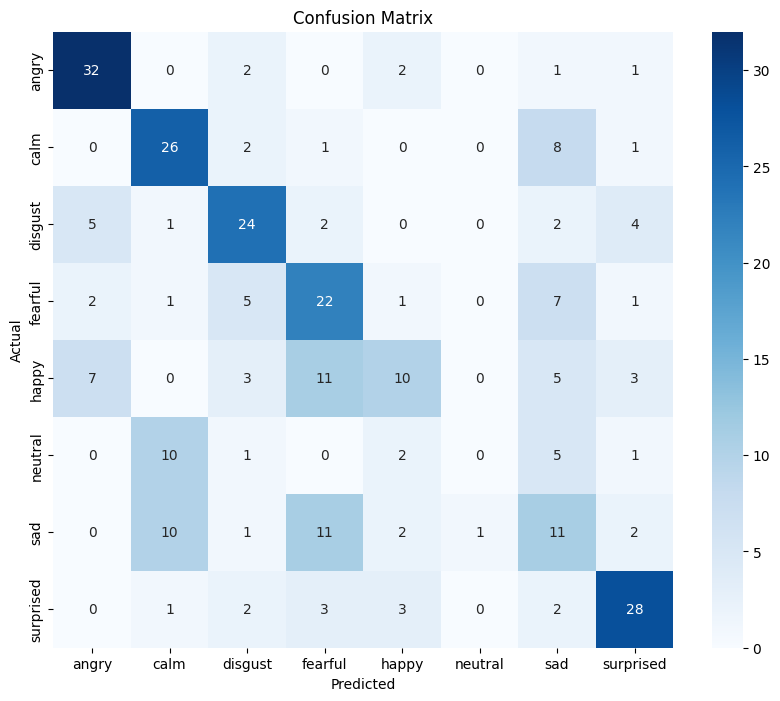

In [45]:
import seaborn as sns

plt.figure(figsize=(10,8))

cm = confusion_matrix(
    all_labels,
    all_predictions
)

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues",

    xticklabels=classes,

    yticklabels=classes

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

# Report Summary

**Dataset:** RAVDESS Emotional Speech Audio Dataset

**Reason for Selection:**
The RAVDESS dataset is a widely used benchmark dataset for speech emotion recognition. It provides balanced emotion classes recorded by professional speakers, making it suitable for evaluating deep learning models.

**Feature Extraction:**
- Audio resampled to 16 kHz
- Fixed duration of 4 seconds
- 40-dimensional MFCC sequences

**Model Architecture:**
- 1-layer LSTM
- Hidden size: 256
- Dropout: 0.3
- Fully connected classifier
- CrossEntropyLoss
- Adam optimizer

**Training Setup:**
- Epochs: 20
- Batch size: 32
- Learning rate: 0.001

**Evaluation Metrics:**
- Accuracy: 53.12%
- Precision: 46.47%
- Recall: 49.82%
- F1-score: 47.34%

The LSTM successfully learned temporal speech representations from MFCC features and demonstrated the feasibility of deep learning for speech emotion classification.

# Observations

The LSTM model successfully learned temporal speech patterns from MFCC sequences extracted from the RAVDESS dataset.

During training, both the training and validation accuracies improved steadily. The validation accuracy reached its highest value of approximately **57.58% around Epoch 17**, after which it decreased slightly while the training accuracy continued to increase. This indicates the beginning of overfitting.

The final test accuracy achieved was **53.12%** with a macro F1-score of **47.34%**. The confusion matrix shows that emotions such as **angry**, **surprised**, and **calm** were recognized more accurately, whereas **neutral**, **happy**, and **sad** were more difficult to classify due to similarities in speech characteristics.

Overall, the experiment demonstrates that LSTM networks can effectively model temporal speech features using MFCC sequences, while also highlighting the challenges involved in speech emotion recognition.